In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

df_confirmed = pd.read_csv('../data/raw/confirmed_global.csv')
df_deaths    = pd.read_csv('../data/raw/deaths_global.csv')
df_recovered = pd.read_csv('../data/raw/recovered_global.csv')
df_owid      = pd.read_csv('../data/raw/owid_covid.csv', parse_dates=['date'])

print("Confirmed:", df_confirmed.shape)
print("Deaths   :", df_deaths.shape)
print("Recovered:", df_recovered.shape)
print("OWID     :", df_owid.shape)

Confirmed: (289, 1147)
Deaths   : (289, 1147)
Recovered: (274, 1147)
OWID     : (429435, 67)


In [3]:
def melt_jhu(df, value_name):
    """Wide format → Long format"""
    id_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
    date_cols = [c for c in df.columns if c not in id_cols]
    
    df_long = df.melt(
        id_vars    = id_cols,
        value_vars = date_cols,
        var_name   = 'date',
        value_name = value_name
    )
    df_long['date'] = pd.to_datetime(df_long['date'], format='%m/%d/%y')
    return df_long

df_conf_long   = melt_jhu(df_confirmed, 'confirmed')
df_deaths_long = melt_jhu(df_deaths,    'deaths')


df = pd.merge(
    df_conf_long,
    df_deaths_long[['Province/State','Country/Region','date','deaths']],
    on  = ['Province/State','Country/Region','date'],
    how = 'left'
)

print(df.shape)
print(df.dtypes)
df.head()

(330327, 7)
Province/State            object
Country/Region            object
Lat                      float64
Long                     float64
date              datetime64[ns]
confirmed                  int64
deaths                     int64
dtype: object


,Province/State,Country/Region,Lat,Long,date,confirmed,deaths
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0


In [4]:

df_country = (
    df.groupby(['Country/Region', 'date'], as_index=False)
      .agg({'confirmed': 'sum', 'deaths': 'sum'})
)


df_country = df_country.sort_values(['Country/Region', 'date'])
df_country['new_cases']  = df_country.groupby('Country/Region')['confirmed'].diff().fillna(0)
df_country['new_deaths'] = df_country.groupby('Country/Region')['deaths'].diff().fillna(0)


df_country['new_cases']  = df_country['new_cases'].clip(lower=0)
df_country['new_deaths'] = df_country['new_deaths'].clip(lower=0)

print(f"Countries: {df_country['Country/Region'].nunique()}")
print(f"Date range: {df_country['date'].min()} → {df_country['date'].max()}")
df_country.head(10)

Countries: 201
Date range: 2020-01-22 00:00:00 → 2023-03-09 00:00:00


,Country/Region,date,confirmed,deaths,new_cases,new_deaths
0,Afghanistan,2020-01-22,0,0,0.0,0.0
1,Afghanistan,2020-01-23,0,0,0.0,0.0
2,Afghanistan,2020-01-24,0,0,0.0,0.0
3,Afghanistan,2020-01-25,0,0,0.0,0.0
4,Afghanistan,2020-01-26,0,0,0.0,0.0
5,Afghanistan,2020-01-27,0,0,0.0,0.0
6,Afghanistan,2020-01-28,0,0,0.0,0.0
7,Afghanistan,2020-01-29,0,0,0.0,0.0
8,Afghanistan,2020-01-30,0,0,0.0,0.0
9,Afghanistan,2020-01-31,0,0,0.0,0.0


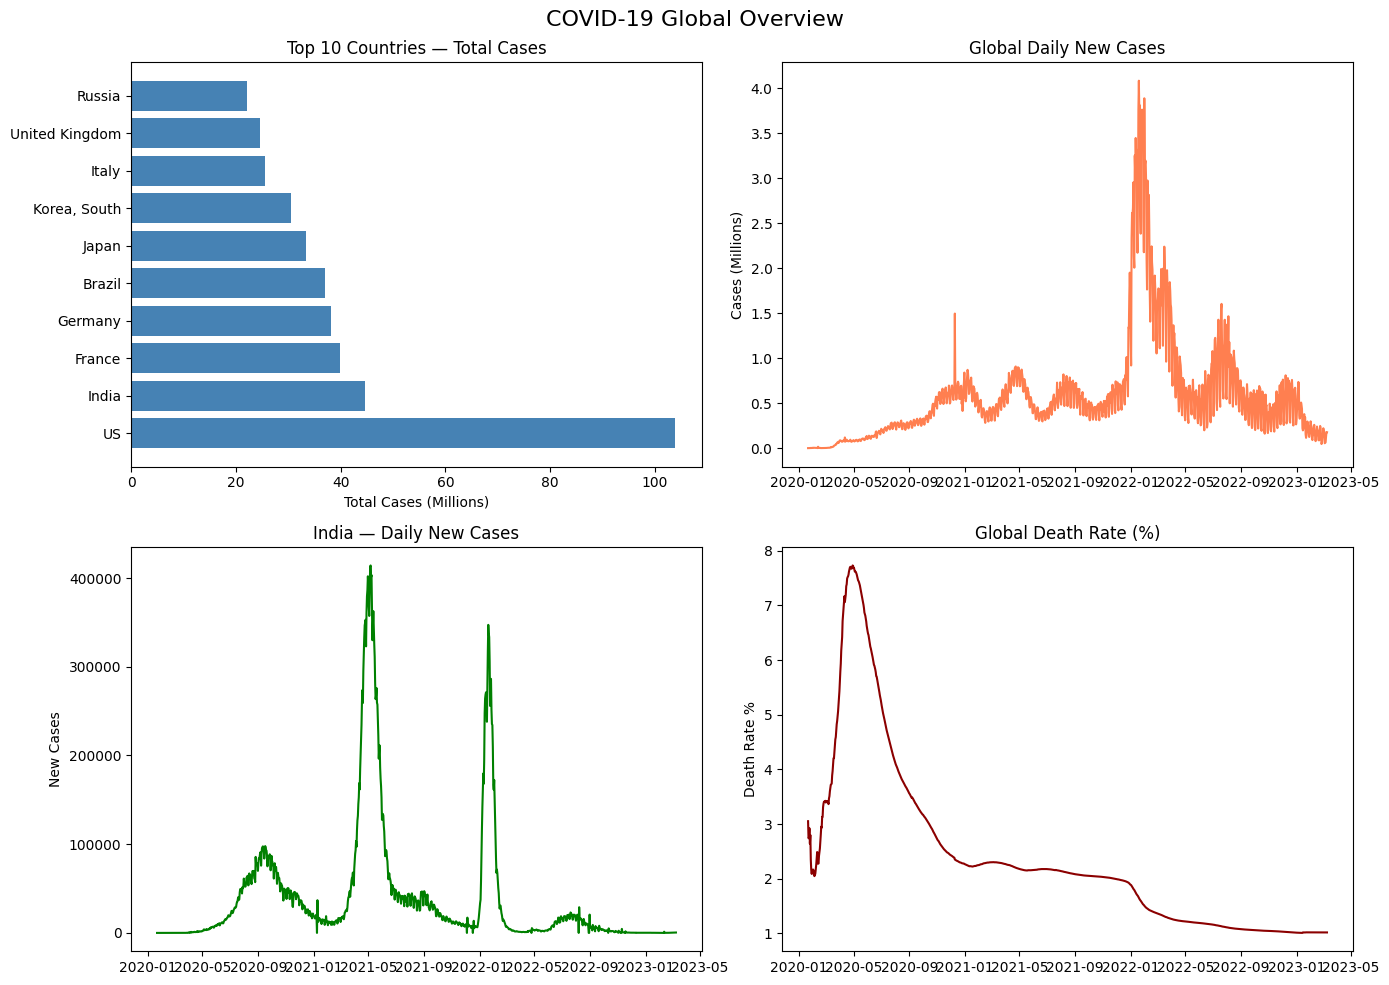

Plot saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('COVID-19 Global Overview', fontsize=16)

# Plot 1: Top 10 countries by total cases
top10 = (df_country.groupby('Country/Region')['confirmed']
         .max().nlargest(10).reset_index())
axes[0,0].barh(top10['Country/Region'], top10['confirmed'] / 1e6, color='steelblue')
axes[0,0].set_xlabel('Total Cases (Millions)')
axes[0,0].set_title('Top 10 Countries — Total Cases')

# Plot 2: Global daily new cases
global_daily = df_country.groupby('date')['new_cases'].sum().reset_index()
axes[0,1].plot(global_daily['date'], global_daily['new_cases'] / 1e6, color='coral')
axes[0,1].set_title('Global Daily New Cases')
axes[0,1].set_ylabel('Cases (Millions)')

# Plot 3: India trend
india = df_country[df_country['Country/Region'] == 'India']
axes[1,0].plot(india['date'], india['new_cases'], color='green')
axes[1,0].set_title('India — Daily New Cases')
axes[1,0].set_ylabel('New Cases')

# Plot 4: Death rate over time (global)
global_agg = df_country.groupby('date')[['confirmed','deaths']].sum()
global_agg['death_rate'] = global_agg['deaths'] / global_agg['confirmed'].replace(0, np.nan) * 100
axes[1,1].plot(global_agg.index, global_agg['death_rate'], color='darkred')
axes[1,1].set_title('Global Death Rate (%)')
axes[1,1].set_ylabel('Death Rate %')

plt.tight_layout()
plt.savefig('../data/raw/eda_overview.png', dpi=150)
plt.show()
print("Plot saved!")

In [6]:
df_country.to_csv('../data/processed/covid_country_daily.csv', index=False)
print(f"Saved! Shape: {df_country.shape}")
print(df_country[df_country['Country/Region']=='India'].tail(5))

Saved! Shape: (229743, 6)
      Country/Region       date  confirmed  deaths  new_cases  new_deaths
92578          India 2023-03-05   44689327  530775      281.0         0.0
92579          India 2023-03-06   44689593  530775      266.0         0.0
92580          India 2023-03-07   44689919  530775      326.0         0.0
92581          India 2023-03-08   44690298  530776      379.0         1.0
92582          India 2023-03-09   44690738  530779      440.0         3.0
